# Generative Adversarial Networks 2

In [1]:
import warnings
warnings.simplefilter('ignore')

import keras

import numpy as np
import tensorflow as tf
print(f"tensorflow version: {tf.__version__}")

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2DTranspose,BatchNormalization,ReLU,Conv2D,LeakyReLU

import matplotlib.pyplot as plt

%matplotlib inline


import os
from os import listdir
from pathlib import Path
import imghdr

import time
from tqdm.auto import tqdm


tensorflow version: 2.21.0


Due to the strong instabiliity of conventional GAN architectures, a followup development was created. Using Convolutional Neural Networks in the GAN architecture imporves results. A simple version of this DCGAN architecture is implemented here.

The following steps are taken to improve performance and stability:

- Replace any pooling layers with **strided convolutions (discriminator)** and **fractional-strided
convolutions (generator)**.
- Use **batchnorm** in both the generator and the discriminator.
- **Remove fully connected hidden layers** for deeper architectures.
- Use **ReLU** activation in generator for all layers except for the output, which uses **Tanh**.
- Use **LeakyReLU** activation in the discriminator for all layers except for the output, which uses **Sigmoid**.
- Use **Adam optimizer**.

In [2]:
## HELPER FUNCTIONS
def plot_array(X, title=""):
    
    plt.rcParams['figure.figsize'] = (20,20) 

    for i,x in enumerate(X):
        x = x.numpy()
        max_ = x.max()
        min_ = x.min()
        xnew = np.uint(255*(x-min_)/(max_-min_))
        plt.subplot(1,5,i+1)
        plt.imshow(xnew)
        plt.axis("off")

    plt.show()

The dataset we'll use is an image dataset of anime faces. Below we load the images by creating a Tensorflow Dataset (`tf.data.Dataset`) with the help of the `.image_dataset_from_directory()` function. The Dataset will provide batches of 128 `[64, 64]` images. We also add caching and image normalisation to the input pipeline.

In [3]:
img_height, img_width, batch_size = (64, 64, 128)

train_ds = (
    tf
    .keras
    .utils
    .image_dataset_from_directory(directory='./data/cartoon_20000',
                                  image_size=(img_height, img_width),
                                  batch_size=batch_size,
                                  label_mode=None)
)

AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
normalization_layer = layers.Rescaling(scale= 1./127.5, offset=-1)
normalized_ds = train_ds.map(lambda x: normalization_layer(x))

Found 20000 files.


Then we can grab a single batch of 128 images. This is returned as 

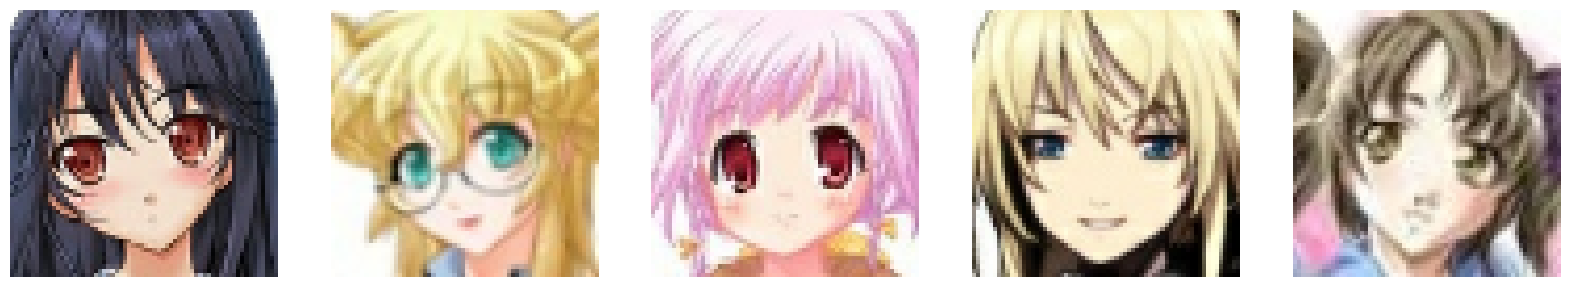

In [4]:
# Take a single batch of images
images = train_ds.unbatch().take(5)
plot_array(images)

## Generator



The following architecture is inspired by [DCGAN in pytorch and tensorflow](https://learnopencv.com/deep-convolutional-gan-in-pytorch-and-tensorflow/)

In [5]:
def make_generator():
    
    model=Sequential()
    
    # input is latent vector of 100 dimensions
    model.add(Input(shape=(1, 1, 100), name='input_layer'))
    
    # Block 1 dimensionality of the output space  64 * 8
    model.add(Conv2DTranspose(64 * 8, kernel_size=4, strides= 4, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_transpose_1'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8, center=1.0, scale=0.02, name='bn_1'))
    model.add(ReLU(name='relu_1'))

    # Block 2: input is 4 x 4 x (64 * 8)
    model.add(Conv2DTranspose(64 * 4, kernel_size=4, strides= 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_transpose_2'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8, center=1.0, scale=0.02, name='bn_2'))
    model.add(ReLU(name='relu_2'))

    # Block 3: input is 8 x 8 x (64 * 4)
    model.add(Conv2DTranspose(64 * 2, kernel_size=4,strides=  2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_transpose_3'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8,  center=1.0, scale=0.02, name='bn_3'))
    model.add(ReLU(name='relu_3'))

                       
    # Block 4: input is 16 x 16 x (64 * 2)
    model.add(Conv2DTranspose(64 * 1, kernel_size=4, strides= 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_transpose_4'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8,  center=1.0, scale=0.02, name='bn_4'))
    model.add(ReLU(name='relu_4'))

    model.add(Conv2DTranspose(3, 4, 2,padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, 
                              activation='tanh', name='conv_transpose_5'))

    return model

gen = make_generator()
gen.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_transpose_1                │ (None, 4, 4, 512)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 4, 4, 512)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_2                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (ReLU)                   │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_3                │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (ReLU)                   │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_4                │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (ReLU)                   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_5                │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,578,624 (13.65 MB)

 Trainable params: 3,576,704 (13.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

### The Discriminator

The Discriminator has five convolution layers. 

- All but the first and final Conv2D layers have Batch Normalization, since directly applying batchnorm to all layers could result in sample oscillation and model instability; 
- The first four Conv2D layers use the **Leaky-Relu activation** with a slope of 0.2. 
- Lastly, instead of a fully connected layer, the  output layer has a convolution layer with a **Sigmoid activation** function.

In [6]:
def make_discriminator():
    
    model=Sequential()
    
    # Block 1: input is 64 x 64 x (3)
    model.add(Input(shape=(64, 64, 3), name='input_layer'))
    model.add(Conv2D(64, kernel_size=4, strides= 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_1'))
    model.add(LeakyReLU(0.2, name='leaky_relu_1'))

    # Block 2: input is 32 x 32 x (64)
    model.add(Conv2D(64 * 2, kernel_size=4, strides= 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_2'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8, center=1.0, scale=0.02, name='bn_1'))
    model.add(LeakyReLU(0.2, name='leaky_relu_2'))

    # Block 3
    model.add(Conv2D(64 * 4, 4, 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_3'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8, center=1.0, scale=0.02, name='bn_2'))
    model.add(LeakyReLU(0.2, name='leaky_relu_3'))


    #Block 4
    model.add(Conv2D(64 * 8, 4, 2, padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False, name='conv_4'))
    model.add(BatchNormalization(momentum=0.1,  epsilon=0.8, center=1.0, scale=0.02, name='bn_3'))
    model.add(LeakyReLU(0.2, name='leaky_relu_4'))


    #Block 5
    model.add(Conv2D(1, 4, 2,padding='same', kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02), use_bias=False,  
                     activation='sigmoid', name='conv_5'))

    return model 

disc = make_discriminator()
disc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 64)     │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 256)      │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_3 (LeakyReLU)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 4, 4, 512)      │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 4, 4, 512)      │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_4 (LeakyReLU)        │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5 (Conv2D)                 │ (None, 2, 2, 1)        │         8,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,767,360 (10.56 MB)

 Trainable params: 2,765,568 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Defining Loss Functions

As we discussed in the previous lab, the min-max optimization problem can be formulated by minimizing the cross entropy loss for the Generator and Discriminator.  

The `cross_entropy` object is the Binary Cross Entropy loss that will be used to model the objectives of the two networks.

In [7]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(Xhat):
    return cross_entropy(tf.ones_like(Xhat), Xhat)

def discriminator_loss(X, Xhat):
    real_loss = cross_entropy(tf.ones_like(X), X)
    fake_loss = cross_entropy(tf.zeros_like(Xhat), Xhat)
    total_loss = 0.5*(real_loss + fake_loss)
    return total_loss

## Defining Optimizers 
 
We create two Adam optimizers for the discriminator and the generator, respectively. We pass the following arguments to the optimizers:

- learning rate of 0.0002.
- beta coefficients $\beta_1 = 0.5$ and $\beta_2 = 0.999$, which are responsible for computing the running averages of the gradients during backpropagation.


In [8]:
learning_rate = 0.0002
generator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999)

## Training Step

Below, we define a single train step for the complete architecture:

- First, we sample `z`, a batch of noise vectors from a normal distribution ($\mu = 1, \sigma = 1$) and feed it to the Generator.
- The Generator produces generated or "fake" images `xhat`.
- We feed real images `X` and fake images `xhat` to the Discriminator and obtain `real_output` and `fake_output` respectively as the scores.
- We calculate Generator loss `gen_loss` using the `fake_output` from Discriminator since we want the fake images to fool the Discriminator as much as possible.
- We calculate Discriminator loss `disc_loss` using both the `real_output` and `fake_output` since we want the Discriminator to distinguish the two as much as possible.
- We calculate `gradients_of_generator` and  `gradients_of_discriminator` based on the losses obtained.
- Finally, we update the Generator and Discriminator by letting their respective optimizers apply the processed gradients on the trainable model parameters.


In [9]:
@tf.function
def train_step(X):
    
    # Random samples it was found if you increase the standard deviation, you get better results 
    z = tf.random.normal([BATCH_SIZE, 1, 1, latent_dim])
      # Needed to compute the gradients for a list of variables.
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generated sample 
        xhat = generator(z, training=True)
        # The output of the discriminator for real data 
        real_output = discriminator(X, training=True)
        # The output of the discriminator for fake data
        fake_output = discriminator(xhat, training=True)
        
        # loss for each 
        gen_loss= generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
      # Compute the gradients for gen_loss and generator
    
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    # Compute the gradients for gen_loss and discriminator
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    # Ask the optimizer to apply the processed gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

To illustrate this, below we use the generator to process some random noise. Since the generator has not been trained yet, the output is not resembling anything at this point.

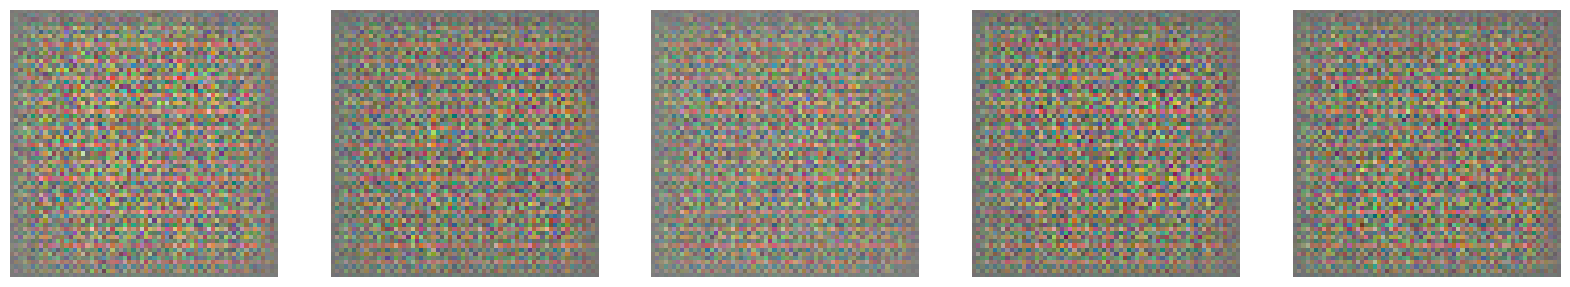

In [10]:
generator= make_generator()
BATCH_SIZE=128

latent_dim=100
noise = tf.random.normal([BATCH_SIZE, 1, 1, latent_dim])
Xhat = generator(noise,training = False)
plot_array(Xhat[0:5])

## Training

This model is quite computationally intensive. There are `2,765,568 `+ `3,576,704` trainable parameters in the model. So we only train for a single epoch and see how far we get with that. 

In [13]:
epochs = 1
discriminator = make_discriminator()
generator = make_generator()

for epoch in range(epochs):
    
    # Data for the true distribution of your real data samples training ste
    start = time.time()
    i = 0
    for X in tqdm(normalized_ds, desc=f"epoch {epoch+1}", total = len(normalized_ds)):
        
        i += 1
        if i % 1000 == 0:
            print("epoch {}, iteration {}".format(epoch+1, i))
            
        train_step(X)
    
    noise = tf.random.normal([BATCH_SIZE, 1, 1, latent_dim])
    Xhat = generator(noise,training=False)
    X = normalized_ds.unbatch().take(5)
    print("orignal images")
    plot_array(X)
    print("generated images")
    plot_array(Xhat[0:5])
    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

epoch 1:   0%|          | 0/157 [00:00<?, ?it/s]

ValueError: in user code:

    File "C:\Users\flori\AppData\Local\Temp\ipykernel_10192\1800778921.py", line 24, in train_step  *
        generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    File "c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 462, in apply_gradients  **
        self.apply(grads, trainable_variables)
    File "c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 503, in apply
        self._check_variables_are_known(trainable_variables)
    File "c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 408, in _check_variables_are_known
        raise ValueError(

    ValueError: Unknown variable: <Variable path=sequential_6/conv_transpose_1/kernel, shape=(4,

This i not really an improvement. We could train the model with more data and for more epochs, and it would likely improve. Running this locally would result in an anormous amount of training time. But luckily we are provided with pretrained weights for this architecture.

### Pretrained model

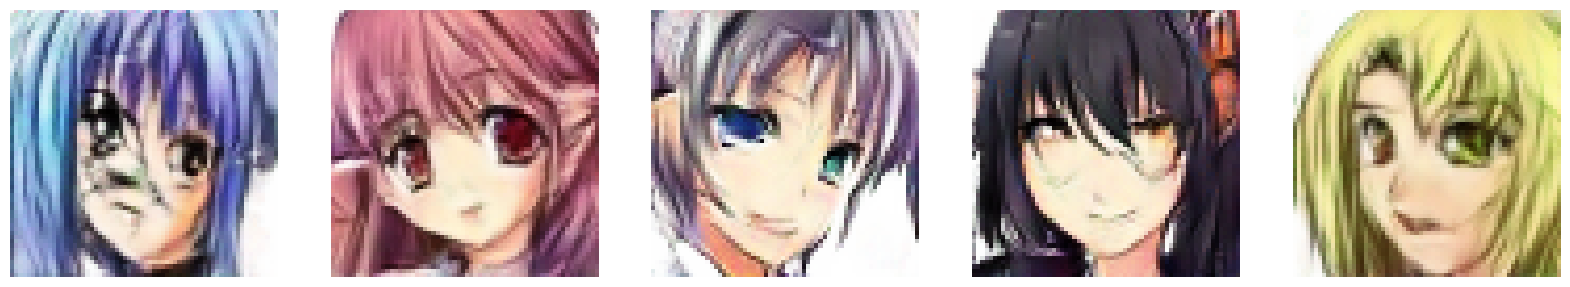

In [24]:
from tensorflow.keras.models import load_model

full_generator=keras.layers.TFSMLayer("./data/generator", call_endpoint='serving_default')

latent_dim = 100

# input consists of noise vectors
noise = tf.random.normal([200, 1, 1, latent_dim])

# feed the noise vectors to the generator
Xhat = full_generator(noise, training=False)
plot_array(Xhat["conv_transpose_5"][0:5])

Which actually produces recognisable images of faces. Though when you look a little closer there are obvious problems. Locally the faces are quite consistent. But globally, in terms of symmetry, there are significant errors.

## Exploring the latent space

The latent representation in this model lies at the input of the generator. Depending on the noise vector we use as input, the output face is generated. It might be expected that when two input noise vectors are close together, the output faces will also be similar. In that way, consistency is similar to the way a VAE latent space works.

Below we plot five different generated faces for input vectors that are multiples of each other.

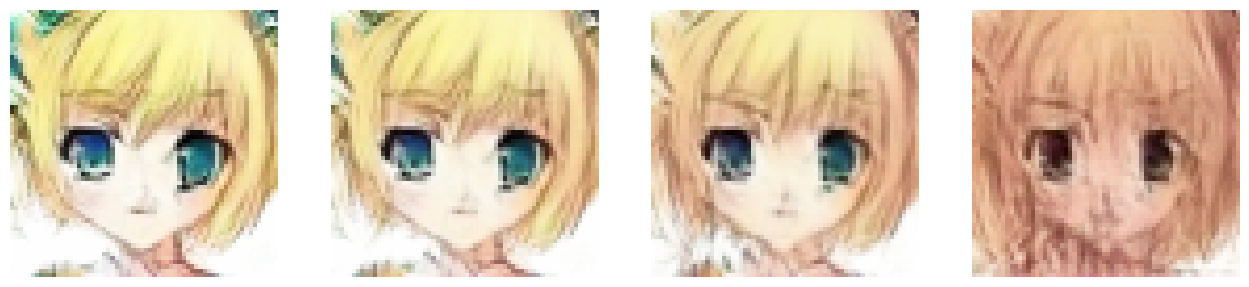

In [28]:
result = []
for c in [1,0.8,0.6,0.4]:
    Xhat = full_generator(c*tf.ones([1, 1, 1, latent_dim]),training=False) # latent_dim = 100 defined previously
    result.append(Xhat["conv_transpose_5"][0])
plot_array(result)

This seems to hold, though the closer we get towards 0, the more distortion happens. This makes sense since the latent space is likely more dense here.

Another set of inputs we can try is in the other direction`[-1,-0.8,-0.6,-0.4]`

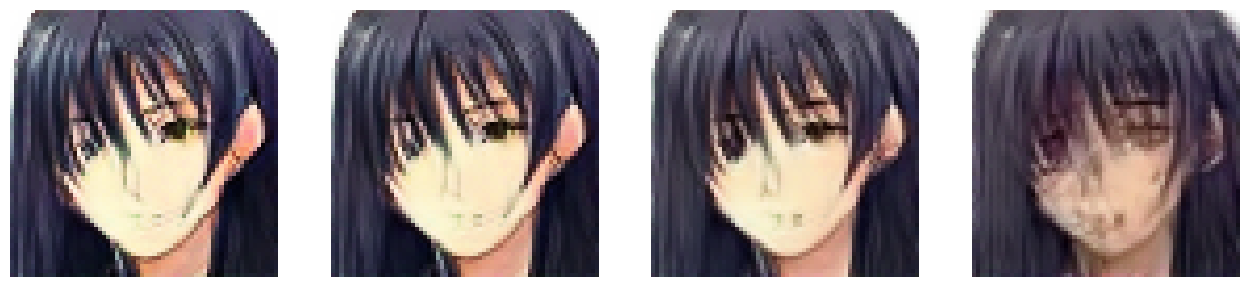

In [ ]:
result = []
for c in [-1,-0.8,-0.6,-0.4]:
    Xhat = full_generator(c*tf.ones([1, 1, 1, latent_dim]),training=False) # latent_dim = 100 defined previously
    result.append(Xhat["conv_transpose_5"][0])
plot_array(result)

Another thing we can try is to set progressively more items from the latent vector representatio to the same value.

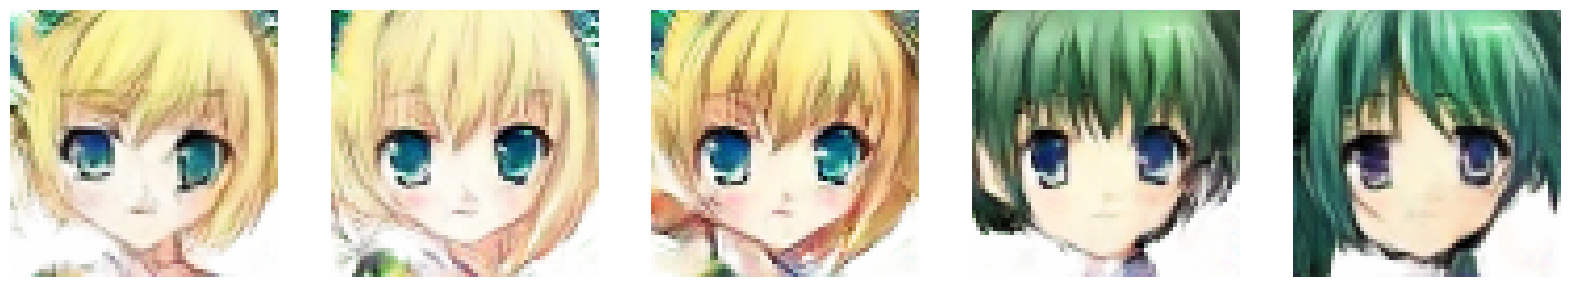

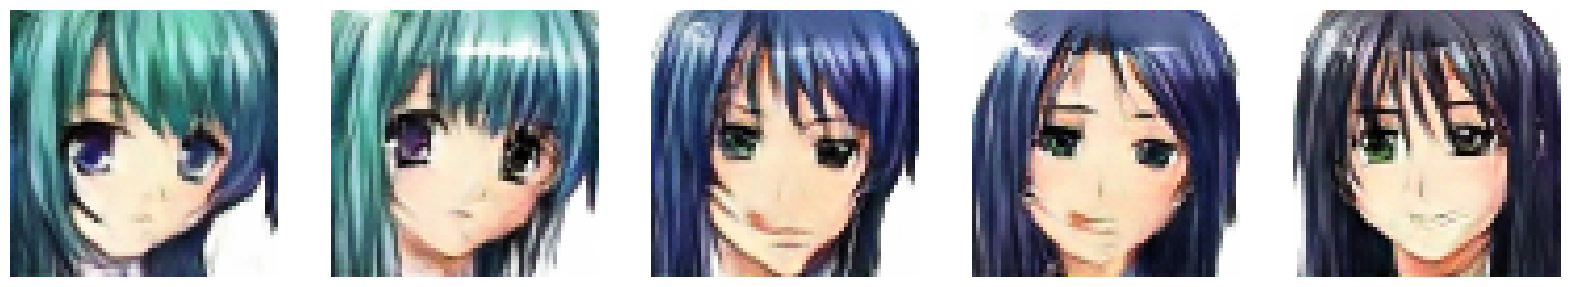

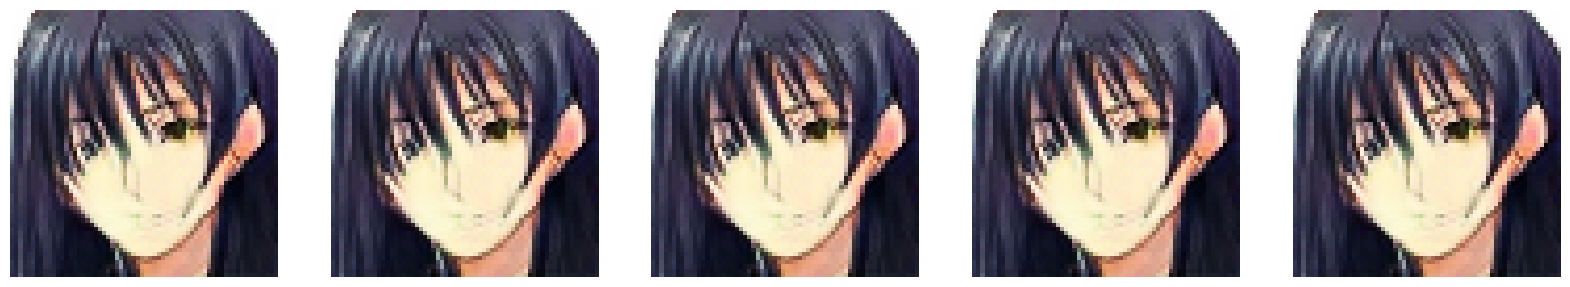

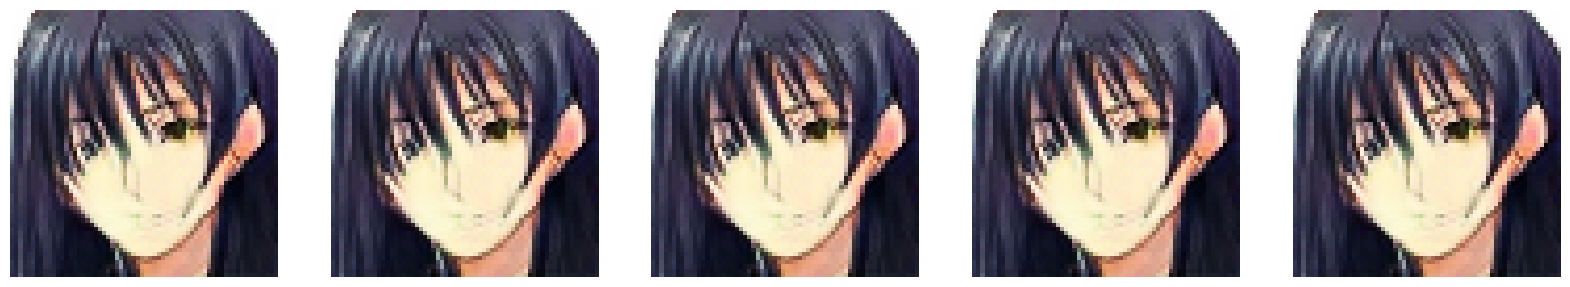

In [41]:
z = np.ones( (1, 1, 1, latent_dim))
for i in [0, 1, 2, 3]:
    res = []
    for n in range(i*5, (i+1)*5):
        z[0, 0, 0, 0:10*n] = -1
        Xhat = full_generator(z, training=False)
        #print("elements from 0 to {} is set to -1".format(10*n))
        res.append(Xhat["conv_transpose_5"][0])
    plot_array(res)

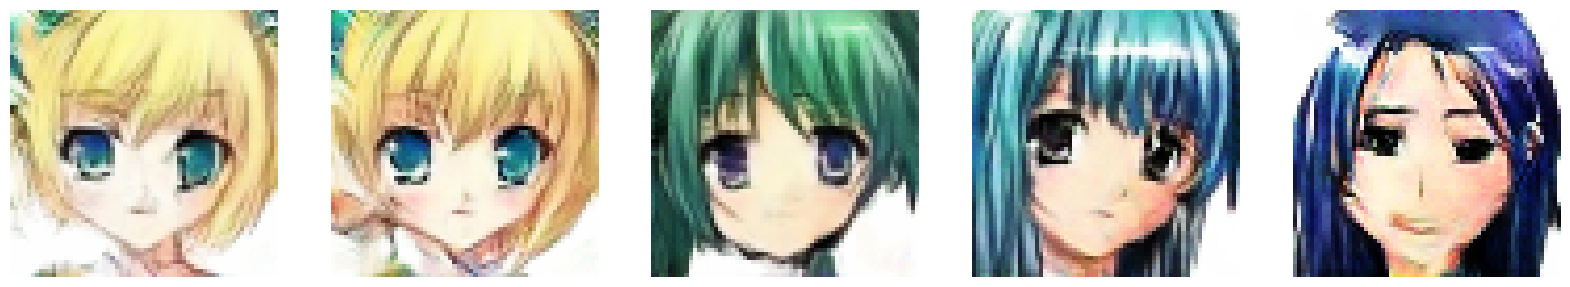

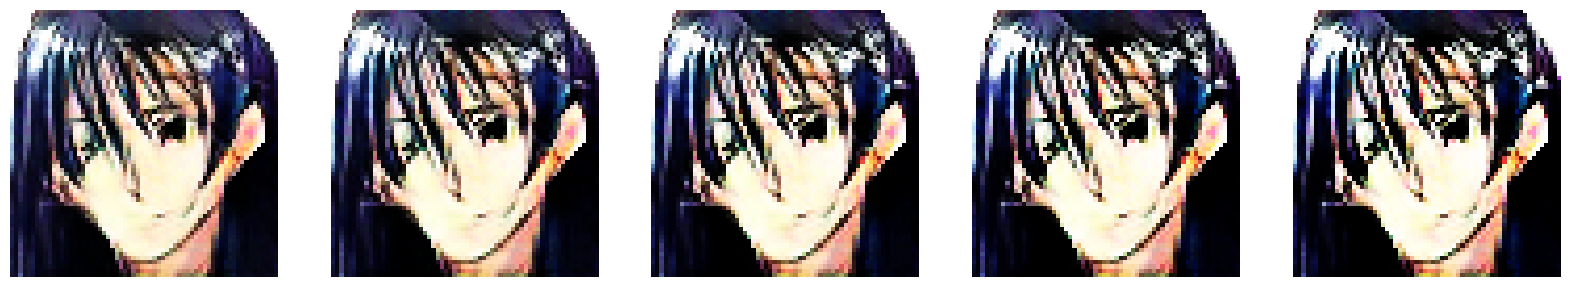

In [42]:
z = np.ones( (1, 1, 1, latent_dim))
for i in [0, 1]:
    res = []
    for n in range(i*5, (i+1)*5):
        z[0, 0, 0, 0:20*n] = -0.5*n
        Xhat = full_generator(z, training=False)
        #print("elements from 0 to {} is set to -1".format(10*n))
        res.append(Xhat["conv_transpose_5"][0])
    plot_array(res)

Or generate fully random vectors and keep a subset of components fixed.

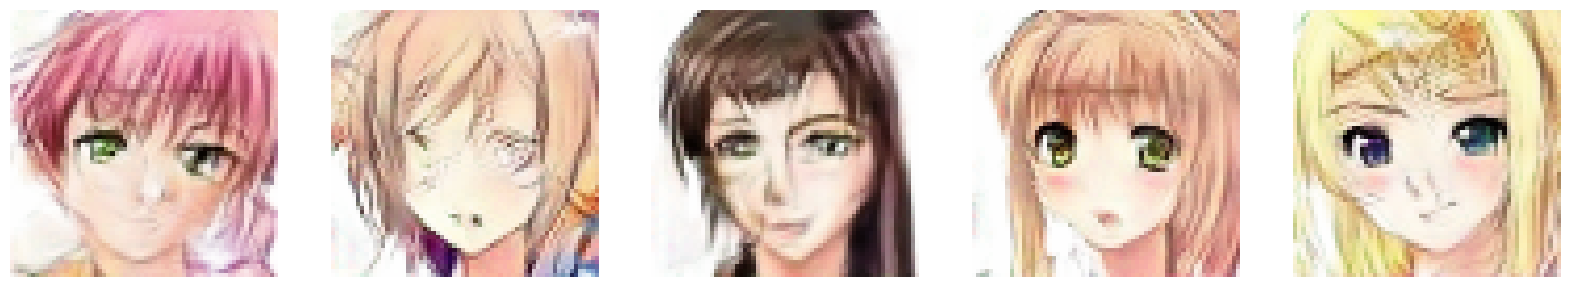

In [ ]:
res = []
for n in range(5):
    z = np.random.normal(0, 1, (1, 1, 1, latent_dim))
    z[0,0,0,0:35] = 1
    Xhat = full_generator(z,training=False)
    res.append(Xhat["conv_transpose_5"][0])
plot_array(res)

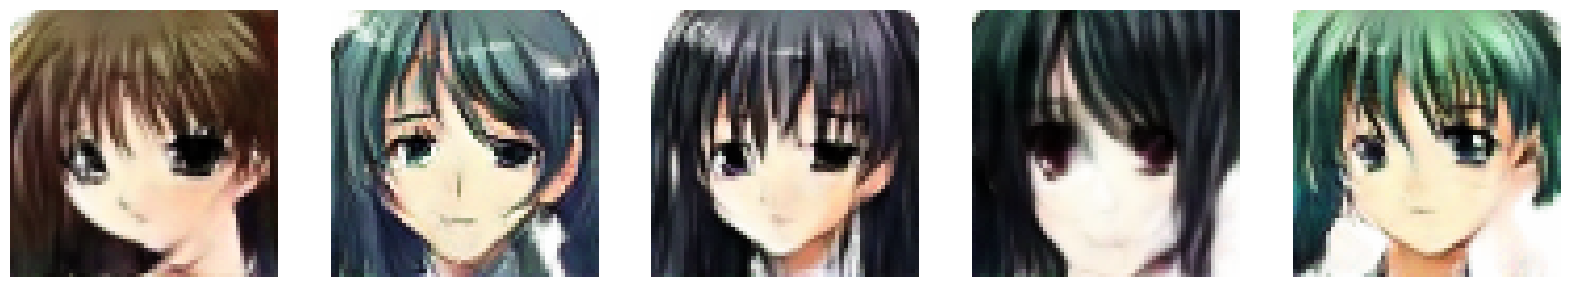

: 

In [ ]:
res = []
for n in range(5):
    z = np.random.normal(0, 1, (1, 1, 1, latent_dim))
    z[0,0,0,0:35] = -1
    Xhat = full_generator(z,training=False)
    res.append(Xhat["conv_transpose_5"][0])
plot_array(res)

One thing we can see from this is that generally the more dimensions tend towards the negative region of the space, the hair color becomes darker. This is a correlation that the model has learned to distill from the latent space.